--- First 10 Rows ---
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement hotwaterheating airconditioning  parking prefarea furnishingstatus
0  13300000   7420         4          2        3      yes        no       no              no             yes        2      yes        furnished
1  12250000   8960         4          4        4      yes        no       no              no             yes        3       no        furnished
2  12250000   9960         3          2        2      yes        no      yes              no              no        2      yes   semi-furnished
3  12215000   7500         4          2        2      yes        no      yes              no             yes        3      yes        furnished
4  11410000   7420         4          1        2      yes       yes      yes              no             yes        2       no        furnished
5  10850000   7500         3          3        1      yes        no      yes              no             yes      

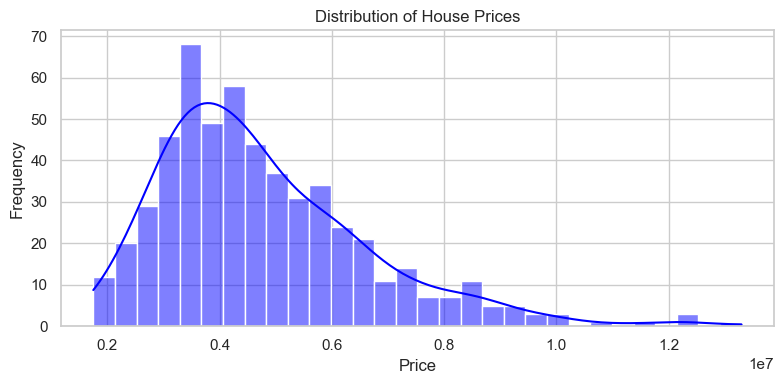

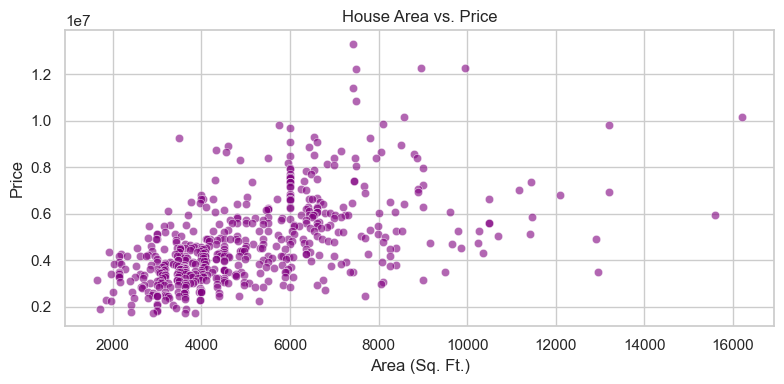

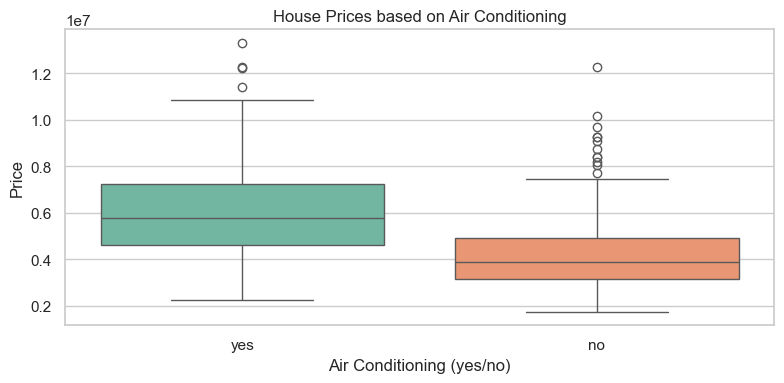

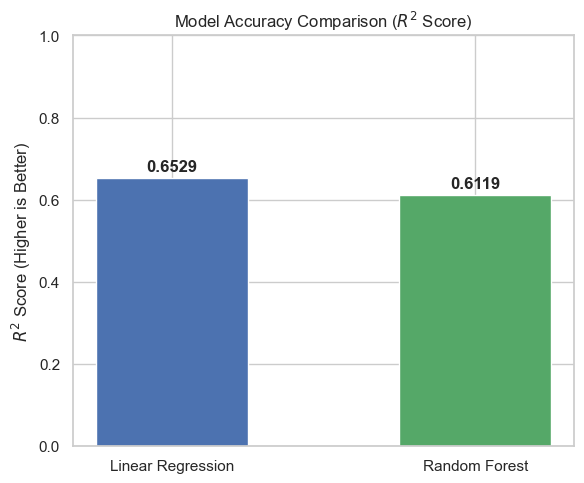

In [11]:
import pandas as pd
import numpy as np               # Added for np.sqrt
import os                     # Added for os.path.exists
import matplotlib.pyplot as plt  # Added for data visualization
import seaborn as sns            # Added for data visualization

# Show all columns and rows in the print output without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor  # Added for Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Added mean_absolute_error

# 1. Load the CSV file
df = pd.read_csv('Housing.csv')

# 2. Data Exploration
print("--- First 10 Rows ---")
print(df.head(10))

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

# 3. Data Cleaning
df = df.drop_duplicates()

# Identify categorical columns to encode
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
# Convert categorical columns into numeric form
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n--- Shape After Encoding ---")
print(df_encoded.shape)

# 4. Separate features and target (FIXED: Changed df_clean to df_encoded)
X = df_encoded.drop(columns=["price"])  # features
y = df_encoded["price"]                 # target variable

# 5. Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train and evaluate Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("\n--- Linear Regression Metrics ---")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)
print("-------------------------------------------------------------------")

# 7. Train and evaluate Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("--- Random Forest Metrics ---")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)
print("-------------------------------------------------------------------")

# 8. Data Visualization (Task 4)
if not os.path.exists('charts'):
    os.makedirs('charts')

sns.set_theme(style="whitegrid")

# Chart 1: Price Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='blue', bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/price_distribution.png')
plt.show()

# Chart 2: Area vs Price
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='area', y='price', alpha=0.6, color='purple')
plt.title('House Area vs. Price')
plt.xlabel('Area (Sq. Ft.)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('charts/area_vs_price.png')
plt.show()

# Chart 3: AC vs Price
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='airconditioning', y='price', hue='airconditioning', palette='Set2', legend=False)
plt.title('House Prices based on Air Conditioning')
plt.xlabel('Air Conditioning (yes/no)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('charts/ac_vs_price.png')
plt.show()

# 9. Chart 4: Accuracy Comparison Graph
plt.figure(figsize=(6, 5))
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]

bars = plt.bar(models, r2_scores, color=['#4C72B0', '#55A868'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Model Accuracy Comparison ($R^2$ Score)')
plt.ylabel('$R^2$ Score (Higher is Better)')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('charts/model_accuracy_comparison.png')
plt.show()